# **Introduction to Meta-heuristics: Team Work II  - TSP problem**


## **Team Members**
1. m5291087 Tithira Withanaarachchi (Leader)
2. m5291501 Minnah Aamir
3. s1300030 Kohei Kuwana

**Role of Each Member.**


*   **Kohei Kuwana:** Apply GA to the TSP Problem: Includes coding, testing, Creating Presentation slides, Reviewing Report and Presentation slides.

*   **Minnah Amir:** Apply ACO to TSP problem: Includes coding, testing, Creating Presentation Slides, Reviewing Report and Presentation slides.

*   **Tithira Withanaarachchi:** Co-ordinating work, Parameter Optimization of the application of GA and ACO algorithms to TSP Problem: Coding, testing, Documenting with explanations, Creating Visuals of the results, Creating Presentation slides, Reviewing Report and Presentation slides.







# **1. Problem Introduction**

## **1.1 Traveling Salesman Problem (TSP)**

TSP is a problem that seeks to find the route with the minimum total distance traveled (or cost) among all possible routes that visit each of multiple cities exactly once and return to the starting point.

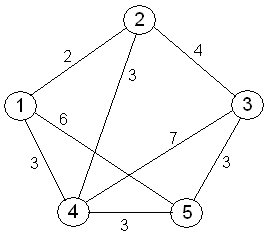

https://commons.wikimedia.org/wiki/File:Example_The_travelling_salesman_problem_(TSP).gif

The method of obtaining the optimal solution by calculating all paths has a time complexity of O(n!) and is NP-hard. We will consider about n=10, 50 100.

# **2. Application of Algorithms**

## **2.0 Initialization**

In [ ]:
pip install optuna

In [ ]:
import random
import math
import optuna
import time
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [ ]:
# n = num of cities, (low, high) = range
def generate_TSP(n, seed=0, low=0.0, high=100.0):
    rnd = random.Random(seed)
    coords = [(rnd.uniform(low, high), rnd.uniform(low, high)) for _ in range(n)]
    return coords

In [ ]:
def build_distance_matrix(coords):
    n = len(coords)
    dist = [[0.0]*n for _ in range(n)]
    for i in range(n):
        x1, y1 = coords[i]
        for j in range(n):
            if i == j:
                continue
            x2, y2 = coords[j]
            dist[i][j] = math.hypot(x1 - x2, y1 - y2)
    return dist

In [ ]:
def tour_length(tour, dist):
    n = len(tour)
    s = 0.0
    for i in range(n):
        s += dist[tour[i]][tour[(i+1) % n]]
    return s

## **2.1 GA**

In [ ]:
def init_ind(n):
        tour = list(range(n))
        random.shuffle(tour)
        return tour

# Order Crossover
def crossover(p1, p2,n):
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))
    child = [None] * n

    # Copy
    child[a:b+1] = p1[a:b+1]

    pos = (b + 1) % n
    for x in p2:
        if x not in child:
            child[pos] = x
            pos = (pos + 1) % n
    return child

def mutate(tour, n):
    i, j = random.sample(range(n), 2)
    tour[i], tour[j] = tour[j], tour[i]


In [ ]:
def GA(dist, generations=400, seed=0, pop_size=80, cx_rate=0.9, mut_rate=0.2, elite_size=2,tournament_k=3):

    n = len(dist)

    # Init
    pop = [init_ind(n) for _ in range(pop_size)]
    best = min(pop, key=lambda t: tour_length(t, dist))
    best_len = tour_length(best, dist)
    GA_best_costs = [];
    for g in range(generations):
        # Evaluate Score
        scored = [(tour_length(ind, dist), ind) for ind in pop]
        scored.sort(key=lambda x: x[0])

        # Update best
        if scored[0][0] < best_len:
            best_len = scored[0][0]
            best = scored[0][1][:]
        GA_best_costs.append(best_len);

        new_pop = [ind[:] for _, ind in scored[:elite_size]]  # Save Elite

        def tournament(k=tournament_k):
            cand = random.sample(scored, k)
            cand.sort(key=lambda x: x[0])
            return cand[0][1][:]

        # Generate new child
        while len(new_pop) < pop_size:
            if random.random() < cx_rate:
                p1 = tournament()
                p2 = tournament()
                child = crossover(p1, p2,n)
            else:
                child = tournament()

            if random.random() < mut_rate:
                mutate(child,n)

            new_pop.append(child)

        pop = new_pop

    return best, best_len, GA_best_costs


In [ ]:
GA_BEST_COST = {"val": float("inf")}
PHASE1_LIMIT_GA = 75   # first 75 trials: cost
def obj_ga( trial: optuna.Trial,dist) -> float:
  pop_size     = trial.suggest_int("population_size", 20, 400, log=True)
  cx_rate      = trial.suggest_float("crossover_rate", 0.6, 1.0)
  mut_rate     = trial.suggest_float("mutation_rate", 1e-3, 0.3, log=True)
  elite_size   = trial.suggest_int("elitism", 0, max(1, pop_size // 10))
  tournament_k = trial.suggest_int("tournament_k", 2, min(10, pop_size))
  if trial.number < PHASE1_LIMIT_GA:
     generations  = trial.suggest_int("generations", 400, 400, log=True)

  else:
    generations  = trial.suggest_int("generations", 50, 400, log=True)

  seeds = (0, 42, 777)
  costs= []
  times = []
  for s in seeds:
      t0 = time.perf_counter()
      _, best_len,_= GA(
          dist,
          generations=generations,
          seed=s,
          pop_size=pop_size,
          cx_rate=cx_rate,
          mut_rate=mut_rate,
          elite_size=elite_size,
          tournament_k=tournament_k
      )
      elapsed = time.perf_counter() - t0

      costs.append(float(best_len))
      times.append(elapsed)

  mean_cost = sum(costs) / len(costs)
  mean_time = sum(times) / len(times)

  # For logging/analysis
  trial.set_user_attr("mean_cost", mean_cost)
  trial.set_user_attr("mean_time", mean_time)

  # ---- Phase 1: trials 0..74 → purely minimize cost ----
  if trial.number < PHASE1_LIMIT_GA:
      if mean_cost < GA_BEST_COST["val"]:
          GA_BEST_COST["val"] = mean_cost
      return mean_cost

  # ---- Phase 2: trials 75.. → minimize time under cost constraint ----
  target = GA_BEST_COST["val"]

  eps = 1e-6  # small tolerance for floating point

  if mean_cost <= target + eps:
      # Good enough cost → now objective is time (smaller is better)
      return mean_time
  else:
      # Worse cost → cannot win, give big penalty
      return 1e6 + mean_cost

## **2.2 ACO**

In [ ]:
def ACO(dist, iterations=400, seed=0, n_ants=None,
        alpha=1.0, beta=5.0, rho=0.1, Q=100.0):

    rnd = random.Random(seed)
    n = len(dist)
    if n_ants is None:
        n_ants = n  # common setting: ants = cities

    # --- Heuristic information η_ij = 1 / d_ij ---
    eta = [[0.0]*n for _ in range(n)]
    for i in range(n):
        for j in range(n):
            if i != j and dist[i][j] > 0:
                eta[i][j] = 1.0 / dist[i][j]

    # --- Pheromone matrix τ_ij (initialized uniformly) ---
    tau0 = 1.0
    tau = [[tau0]*n for _ in range(n)]

    best_tour = None
    best_len = float("inf")

    ACO_best_costs=[]

    # ===================== main loop =====================
    for it in range(iterations):

        tours = []  # store (tour, length) for all ants

        # --------- construct a tour for each ant ----------
        for k in range(n_ants):
            # starting city can be fixed or random; here random
            start = rnd.randrange(n)
            visited = [False]*n
            visited[start] = True
            tour = [start]

            # build tour step by step
            for step in range(n-1):
                i = tour[-1]  # current city

                # compute probabilities for all unvisited cities
                probs = []
                total = 0.0
                for j in range(n):
                    if not visited[j]:
                        tau_ij = tau[i][j] ** alpha
                        eta_ij = eta[i][j] ** beta
                        val = tau_ij * eta_ij
                        probs.append((j, val))
                        total += val

                # roulette-wheel selection
                if total == 0.0:
                    # if all val are zero, choose uniformly
                    candidates = [j for j in range(n) if not visited[j]]
                    j_next = rnd.choice(candidates)
                else:
                    r = rnd.random() * total
                    s = 0.0
                    j_next = probs[-1][0]  # fallback
                    for j, val in probs:
                        s += val
                        if s >= r:
                            j_next = j
                            break

                tour.append(j_next)
                visited[j_next] = True

            # close the tour and evaluate its length
            L = tour_length(tour, dist)
            tours.append((tour, L))

            if L < best_len:
                best_tour = tour[:]
                best_len = L
        ACO_best_costs.append(best_len);#best so far across each iteration


        # --------- pheromone evaporation on all edges -----
        for i in range(n):
            for j in range(n):
                tau[i][j] *= (1.0 - rho)
                if tau[i][j] < 1e-12:  # avoid going to exactly zero
                    tau[i][j] = 1e-12

        # --------- pheromone reinforcement ----------------
        for tour, L in tours:
            if L == 0:
                continue
            deposit = Q / L
            for idx in range(n):
                a = tour[idx]
                b = tour[(idx + 1) % n]
                tau[a][b] += deposit
                tau[b][a] += deposit  # symmetric TSP

    return best_tour, best_len, ACO_best_costs


In [ ]:
ACO_BEST_COST = {"val": float("inf")}
PHASE1_LIMIT_ACO = 40
def obj_aco(trial: optuna.Trial, dist) -> float:
  n_ants = trial.suggest_int("n_ants", 5, 100, log=True)
  alpha = trial.suggest_float("alpha", 0.5, 2.0)
  beta = trial.suggest_float("beta", 1, 15, log=True)
  rho = trial.suggest_int("rho", 0, 1)
  Q = trial.suggest_int("Q", 10, 1000)
  if trial.number < PHASE1_LIMIT_ACO:
    iterations  = trial.suggest_int("iterations", 400, 400, log=True)
  else:
    iterations  = trial.suggest_int("iterations", 50, 400, log=True)

  seeds = (0, 42, 777)
  costs= []
  times= []
  for s in seeds:
    t0 = time.perf_counter()
    _, best_len,_ = ACO(
        dist,
        iterations=iterations,
        seed=s,
        n_ants=n_ants,
        alpha=alpha,
        beta=beta,
        rho=rho,
        Q=Q
    )
    elapsed = time.perf_counter() - t0

    costs.append(float(best_len))
    times.append(elapsed)
  mean_cost = sum(costs) / len(costs)
  mean_time = sum(times) / len(times)

  # For logging/analysis
  trial.set_user_attr("mean_cost", mean_cost)
  trial.set_user_attr("mean_time", mean_time)

  # ---- Phase 1: trials 0..74 → purely minimize cost ----
  if trial.number < PHASE1_LIMIT_ACO:
      if mean_cost < ACO_BEST_COST["val"]:
          ACO_BEST_COST["val"] = mean_cost
      return mean_cost

  # ---- Phase 2: trials 75.. → minimize time under cost constraint ----
  target = ACO_BEST_COST["val"]

  eps = 1e-6  # small tolerance for floating point

  if mean_cost <= target + eps:
      # Good enough cost → objective is time
      return mean_time
  else:
      # Worse cost → big penalty
      return 1e6 + mean_cost

# **3. Intoduction to Optimization.**

In optimization of both the algorithms, there are two phases each for cost optimization and time optimization.

In GA, cost is optimized for 75 trials and time is optimized for remaining 45 trials.

In ACO, cost is optimized for 40 trials, and time is optimized for remaining 80 trials.


The trial limit for cost optimization and Time Optimization is decided by following a pilot study while Optimizing only the cost of GA and ACO seperately for 150 trials.

In GA there was no improvemnt of Cost after the 70th trial and ACO didnt have any significant improvement after 30-40th trials.

Please refer the Appendix section to see the Pilot Study done by only optimizing cost (Tour Length).

# **4. Exection and Results**

In [ ]:
def execute(n):
    print(f"=== n = {n} ===")

    coords = generate_TSP(n)
    dist = build_distance_matrix(coords)

    t0 = time.perf_counter()
    best_tour_ga, best_len_ga, ga_best_costs = GA(dist, generations=400, seed=0, pop_size=80, cx_rate=0.9, mut_rate=0.2, elite_size=2, tournament_k=3)
    elapsed_GA = time.perf_counter() - t0

    t0 = time.perf_counter()
    best_tour_aco, best_len_aco, aco_best_costs = ACO(dist, iterations=400, seed=0)
    elapsed_ACO = time.perf_counter() - t0

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=7))
    study.optimize(lambda trial: obj_ga(trial, dist), n_trials=120)
    params=study.best_params;
    print("Best Params of GA", params)

    t0 = time.perf_counter()
    opt_best_tour_ga, opt_best_len_ga, opt_ga_best_costs = GA(dist, generations=params["generations"], seed=0, pop_size=params["population_size"], cx_rate=params["crossover_rate"], mut_rate=params["mutation_rate"], elite_size=params["elitism"], tournament_k=params["tournament_k"])
    opt_elapsed_GA = time.perf_counter() - t0


    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=7))
    study.optimize(lambda trial: obj_aco(trial, dist), n_trials=120)
    params=study.best_params;
    print("Best Params of ACO", params)

    t0 = time.perf_counter()
    opt_best_tour_aco, opt_best_len_aco, opt_aco_best_costs = ACO(dist, iterations=params["iterations"], seed=0, n_ants=params["n_ants"], alpha=params["alpha"], beta=params["beta"],rho=params["rho"], Q=params["Q"])
    opt_elapsed_ACO = time.perf_counter() - t0

    print("GA best length :", best_len_ga)
    print("GA best tour   :", best_tour_ga)
    print("GA runtime  :", elapsed_GA)
    print("Optimized GA best length :", opt_best_len_ga)
    print("Optimized GA best tour   :", opt_best_tour_ga)
    print("Optimized GA runtime  :", opt_elapsed_GA)
    print("ACO best length:", best_len_aco)
    print("ACO best tour  :", best_tour_aco)
    print("ACO runtime  :", elapsed_ACO)
    print("Optimized ACO best length :", opt_best_len_aco)
    print("Optimized ACO best tour   :", opt_best_tour_aco)
    print("Optimized ACO runtime  :", opt_elapsed_ACO)
    print()

    return (coords, best_tour_ga, best_len_ga, ga_best_costs, elapsed_GA, best_tour_aco, best_len_aco, aco_best_costs, elapsed_ACO, opt_best_tour_ga, opt_best_len_ga, opt_ga_best_costs, opt_elapsed_GA, opt_best_tour_aco, opt_best_len_aco, opt_aco_best_costs, opt_elapsed_ACO)


In [ ]:
def plot_best_tour(coords, tour, title="Best GA TSP tour"):

    # Build x, y lists following the tour order and return to start
    xs = [coords[i][0] for i in tour] + [coords[tour[0]][0]]
    ys = [coords[i][1] for i in tour] + [coords[tour[0]][1]]

    plt.figure(figsize=(6, 6))
    plt.plot(xs, ys, marker='o')

    # Label each city with its index
    for idx in tour:
        x, y = coords[idx]
        plt.text(x, y, str(idx), fontsize=9, ha='right', va='bottom')

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True, alpha=0.3)
    plt.gca().set_aspect('equal', 'box')  # keep aspect ratio
    plt.tight_layout()
    plt.show()

**4.1 Execution of GA(Optimized and Original) and ACO(Optimized and Original) for TSP with 10 Cities.**

In [ ]:
#for 10 cities
coords_10, best_tour_ga_10, best_len_ga_10, ga_best_costs_10, elapsed_GA_10, best_tour_aco_10, best_len_aco_10, aco_best_costs_10, elapsed_ACO_10, opt_best_tour_ga_10, opt_best_len_ga_10, opt_ga_best_costs_10, opt_elapsed_GA_10, opt_best_tour_aco_10, opt_best_len_aco_10, opt_aco_best_costs_10, opt_elapsed_ACO_10=execute(10)


=== n = 10 ===


[I 2025-11-23 16:38:46,843] A new study created in memory with name: no-name-82352f90-37a8-4449-9d12-1cc4eaf59d19
[I 2025-11-23 16:38:47,307] Trial 0 finished with value: 252.2951315440238 and parameters: {'population_size': 25, 'crossover_rate': 0.9119675168960458, 'mutation_rate': 0.012189694614178044, 'elitism': 2, 'tournament_k': 10, 'generations': 400}. Best is trial 0 with value: 252.2951315440238.
[I 2025-11-23 16:38:48,761] Trial 1 finished with value: 244.39257989546687 and parameters: {'population_size': 99, 'crossover_rate': 0.8004481854639751, 'mutation_rate': 0.0015082710453590447, 'elitism': 2, 'tournament_k': 6, 'generations': 400}. Best is trial 1 with value: 244.39257989546687.
[I 2025-11-23 16:38:50,844] Trial 2 finished with value: 239.37246803810783 and parameters: {'population_size': 152, 'crossover_rate': 0.9214956144417502, 'mutation_rate': 0.008782888669095604, 'elitism': 1, 'tournament_k': 4, 'generations': 400}. Best is trial 2 with value: 239.37246803810783.


Best Params of GA {'population_size': 128, 'crossover_rate': 0.6264325132478407, 'mutation_rate': 0.001256314539805212, 'elitism': 11, 'tournament_k': 3, 'generations': 150}


[I 2025-11-23 16:42:23,925] Trial 0 finished with value: 246.449424497893 and parameters: {'n_ants': 6, 'alpha': 1.6698781883601719, 'beta': 3.278002383260733, 'rho': 1, 'Q': 979, 'iterations': 400}. Best is trial 0 with value: 246.449424497893.
[I 2025-11-23 16:42:24,570] Trial 1 finished with value: 239.37246803810783 and parameters: {'n_ants': 24, 'alpha': 1.251680695489907, 'beta': 1.2154545064008528, 'rho': 0, 'Q': 505, 'iterations': 400}. Best is trial 1 with value: 239.37246803810783.
[I 2025-11-23 16:42:25,549] Trial 2 finished with value: 239.37246803810783 and parameters: {'n_ants': 37, 'alpha': 1.705608554156563, 'beta': 2.805572764453646, 'rho': 0, 'Q': 295, 'iterations': 400}. Best is trial 1 with value: 239.37246803810783.
[I 2025-11-23 16:42:27,569] Trial 3 finished with value: 239.37246803810783 and parameters: {'n_ants': 76, 'alpha': 0.8200780303698733, 'beta': 3.4020370539347287, 'rho': 1, 'Q': 34, 'iterations': 400}. Best is trial 1 with value: 239.37246803810783.
[I

Best Params of ACO {'n_ants': 5, 'alpha': 0.8961126748401956, 'beta': 1.9149267753286214, 'rho': 0, 'Q': 272, 'iterations': 53}
GA best length : 239.37246803810783
GA best tour   : [6, 9, 8, 0, 5, 3, 7, 1, 2, 4]
GA runtime  : 0.33881101299994043
Optimized GA best length : 239.37246803810783
Optimized GA best tour   : [5, 3, 7, 1, 2, 4, 6, 9, 8, 0]
Optimized GA runtime  : 0.14930262000052608
ACO best length: 239.37246803810783
ACO best tour  : [3, 7, 1, 2, 4, 6, 9, 8, 0, 5]
ACO runtime  : 0.08955270900150936
Optimized ACO best length : 239.37246803810783
Optimized ACO best tour   : [5, 3, 7, 1, 2, 4, 6, 9, 8, 0]
Optimized ACO runtime  : 0.008192683999368455



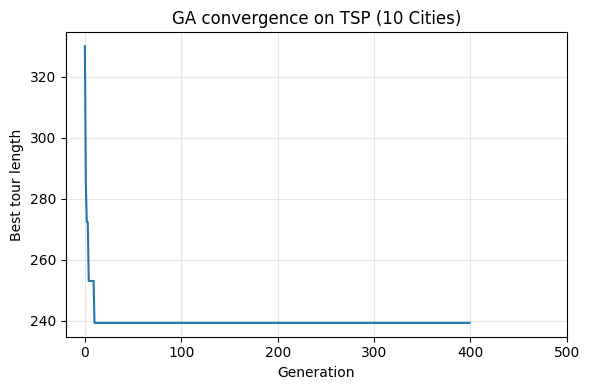

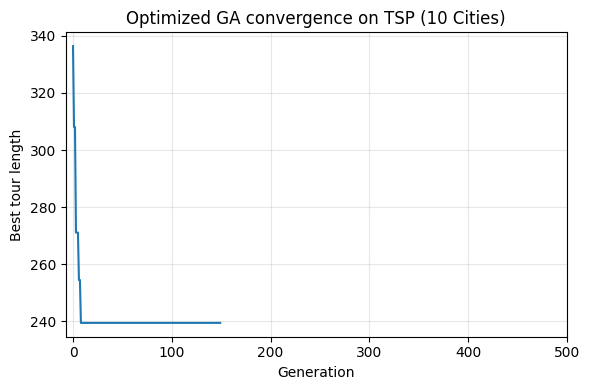

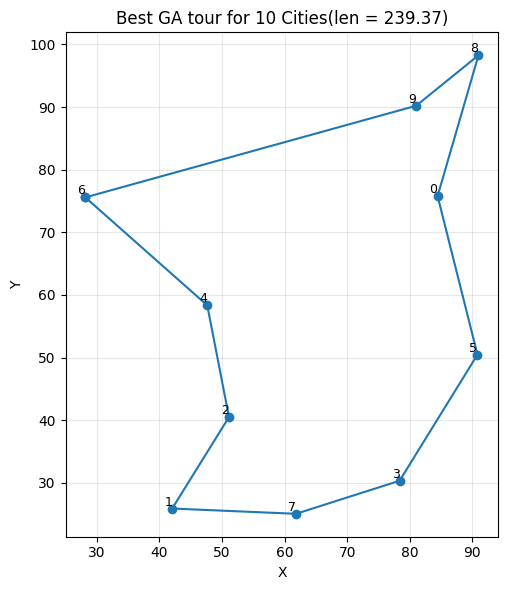

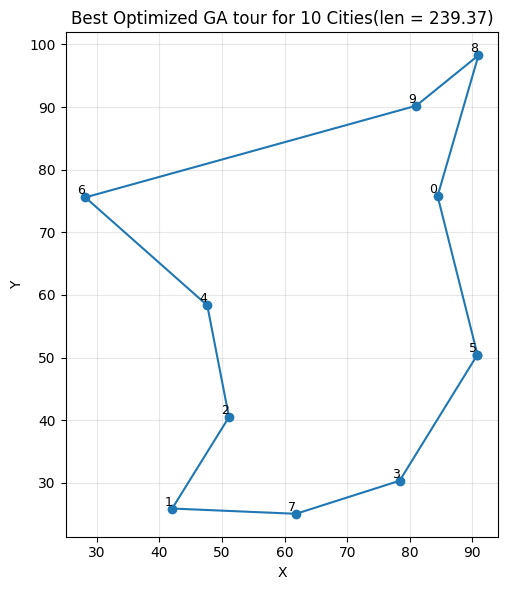

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(ga_best_costs_10)
plt.xlabel("Generation")
plt.ylabel("Best tour length")
plt.title("GA convergence on TSP (10 Cities)")
plt.xlim(xmax=500)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(opt_ga_best_costs_10)
plt.xlabel("Generation")
plt.ylabel("Best tour length")
plt.title("Optimized GA convergence on TSP (10 Cities)")
plt.xlim(xmax=500)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plot_best_tour(coords_10, best_tour_ga_10, title=f"Best GA tour for 10 Cities(len = {best_len_ga_10:.2f})")
plot_best_tour(coords_10, opt_best_tour_ga_10, title=f"Best Optimized GA tour for 10 Cities(len = {opt_best_len_ga_10:.2f})")

When the number of Cities in the TSP problem is 10 cities, both the original GA algorithm and the Optimized version of GA algorithm has achieved the same cost which seems to be the optimal value. According to the result, the tour of both the versions are the same.

According to the convergence Graphs it can be seen that the Optimized version has reduced the number of iterations to reach the final solution which causes an increase in efficiency after optimization.

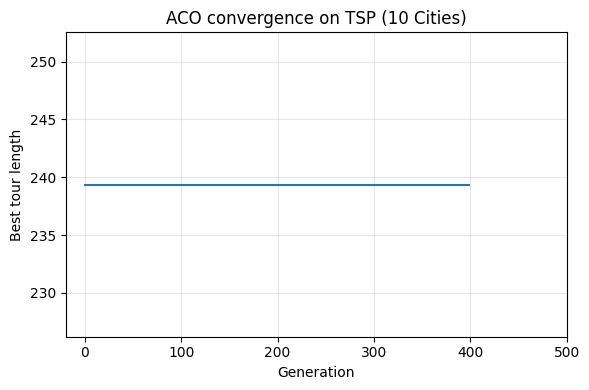

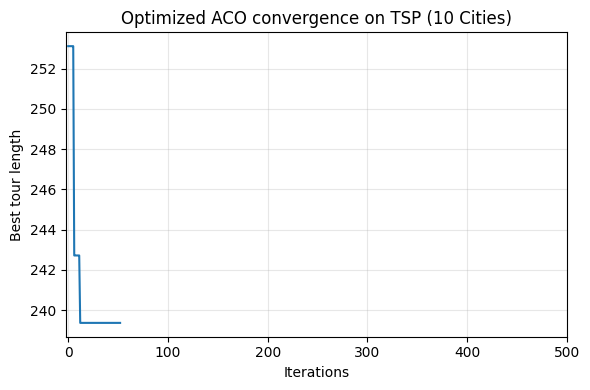

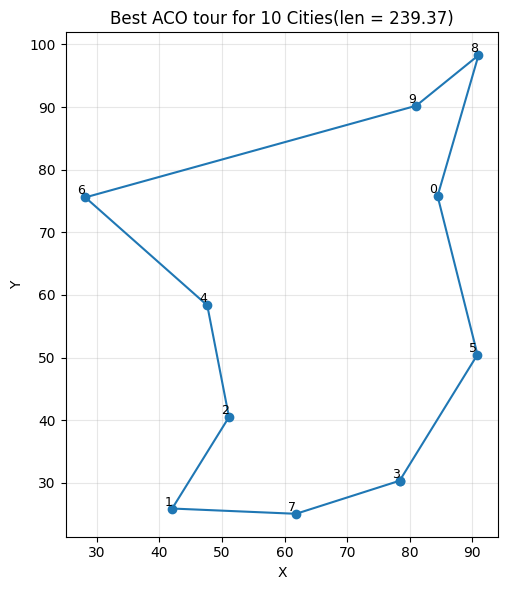

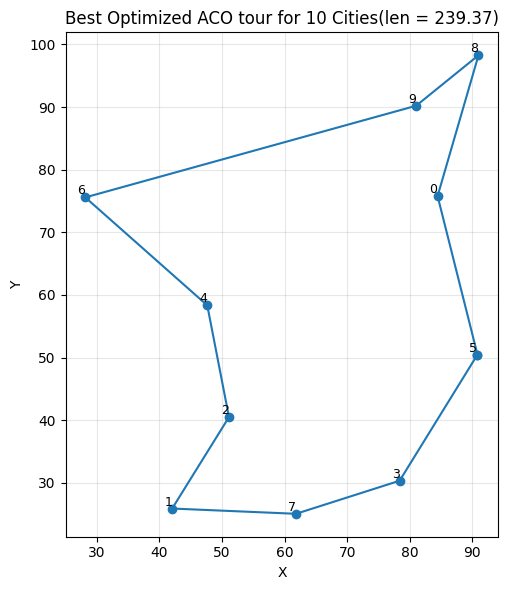

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(aco_best_costs_10)
plt.xlabel("Generation")
plt.ylabel("Best tour length")
plt.title("ACO convergence on TSP (10 Cities)")
plt.xlim(xmax=500)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(opt_aco_best_costs_10)
plt.xlabel("Iterations")
plt.ylabel("Best tour length")
plt.title("Optimized ACO convergence on TSP (10 Cities)")
plt.xlim(xmax=500)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plot_best_tour(coords_10, best_tour_aco_10, title=f"Best ACO tour for 10 Cities(len = {best_len_aco_10:.2f})")
plot_best_tour(coords_10, opt_best_tour_aco_10, title=f"Best Optimized ACO tour for 10 Cities(len = {opt_best_len_aco_10:.2f})")

According to the Convergence graphs, it can be seen that the ACO is easily solving the TSP problem with 10 cities even without optimization(with respect to the cost). However, to increase the efficiency, optimization has been done.

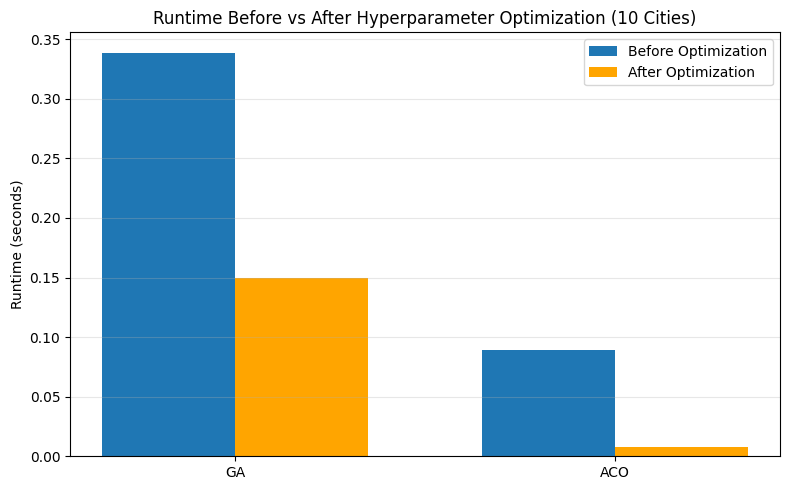

In [ ]:
algos = ["GA", "ACO"]
before = [elapsed_GA_10, elapsed_ACO_10]
after  = [opt_elapsed_GA_10, opt_elapsed_ACO_10]

x = np.arange(len(algos))
w = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - w/2, before, width=w, label="Before Optimization")
plt.bar(x + w/2, after,  width=w, label="After Optimization", color="orange")

plt.xticks(x, algos)
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Before vs After Hyperparameter Optimization (10 Cities)")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

For TSP with 10 cities, both the original and Optimized versions of GA and ACO reach the similar final cost for travelling. However, after optimization, the runtime efficiency of both GA and ACO has improved significantly.

**4.2 Execution of GA(Optimized and Original) and ACO(Optimized and Original) for TSP with 50 Cities.**

In [ ]:
#for 50 cities
coords_50, best_tour_ga_50, best_len_ga_50, ga_best_costs_50, elapsed_GA_50, best_tour_aco_50, best_len_aco_50, aco_best_costs_50, elapsed_ACO_50, opt_best_tour_ga_50, opt_best_len_ga_50, opt_ga_best_costs_50, opt_elapsed_GA_50, opt_best_tour_aco_50, opt_best_len_aco_50, opt_aco_best_costs_50, opt_elapsed_ACO_50=execute(50)

=== n = 50 ===


[I 2025-11-23 16:43:24,699] A new study created in memory with name: no-name-62809aff-c4b7-4feb-b09d-7b845a5919d9
[I 2025-11-23 16:43:25,951] Trial 0 finished with value: 836.3711456073878 and parameters: {'population_size': 25, 'crossover_rate': 0.9119675168960458, 'mutation_rate': 0.012189694614178044, 'elitism': 2, 'tournament_k': 10, 'generations': 400}. Best is trial 0 with value: 836.3711456073878.
[I 2025-11-23 16:43:30,416] Trial 1 finished with value: 701.46688185649 and parameters: {'population_size': 99, 'crossover_rate': 0.8004481854639751, 'mutation_rate': 0.0015082710453590447, 'elitism': 2, 'tournament_k': 6, 'generations': 400}. Best is trial 1 with value: 701.46688185649.
[I 2025-11-23 16:43:38,993] Trial 2 finished with value: 592.0981661002255 and parameters: {'population_size': 152, 'crossover_rate': 0.9214956144417502, 'mutation_rate': 0.008782888669095604, 'elitism': 1, 'tournament_k': 4, 'generations': 400}. Best is trial 2 with value: 592.0981661002255.
[I 2025-

Best Params of GA {'population_size': 314, 'crossover_rate': 0.9372432861728427, 'mutation_rate': 0.0016270669818755654, 'elitism': 23, 'tournament_k': 3, 'generations': 400}


[I 2025-11-23 17:06:38,857] A new study created in memory with name: no-name-1ae2b346-8939-4459-9df9-c3440d3171d4
[I 2025-11-23 17:06:42,106] Trial 0 finished with value: 566.3162934476344 and parameters: {'n_ants': 6, 'alpha': 1.6698781883601719, 'beta': 3.278002383260733, 'rho': 1, 'Q': 979, 'iterations': 400}. Best is trial 0 with value: 566.3162934476344.
[I 2025-11-23 17:06:55,537] Trial 1 finished with value: 544.4504777607625 and parameters: {'n_ants': 24, 'alpha': 1.251680695489907, 'beta': 1.2154545064008528, 'rho': 0, 'Q': 505, 'iterations': 400}. Best is trial 1 with value: 544.4504777607625.
[I 2025-11-23 17:07:16,342] Trial 2 finished with value: 538.4865020478629 and parameters: {'n_ants': 37, 'alpha': 1.705608554156563, 'beta': 2.805572764453646, 'rho': 0, 'Q': 295, 'iterations': 400}. Best is trial 2 with value: 538.4865020478629.
[I 2025-11-23 17:07:57,450] Trial 3 finished with value: 535.8457706009584 and parameters: {'n_ants': 76, 'alpha': 0.8200780303698733, 'beta'

Best Params of ACO {'n_ants': 97, 'alpha': 0.5280794565476233, 'beta': 5.644131714762152, 'rho': 1, 'Q': 17, 'iterations': 400}
GA best length : 759.7132568728946
GA best tour   : [36, 4, 46, 15, 27, 9, 38, 43, 14, 8, 40, 47, 39, 0, 45, 31, 44, 30, 25, 21, 48, 3, 42, 7, 34, 17, 37, 32, 33, 18, 41, 1, 12, 35, 28, 26, 20, 23, 16, 24, 22, 6, 10, 13, 2, 49, 29, 5, 11, 19]
GA runtime  : 1.2590982139990956
Optimized GA best length : 628.6860936500279
Optimized GA best tour   : [27, 24, 16, 10, 46, 13, 4, 36, 29, 30, 5, 45, 31, 0, 43, 38, 9, 8, 14, 47, 40, 39, 11, 19, 44, 25, 33, 2, 41, 32, 49, 18, 42, 3, 21, 48, 17, 12, 37, 7, 34, 1, 26, 35, 20, 28, 23, 6, 22, 15]
Optimized GA runtime  : 4.834442715000478
ACO best length: 536.2562242266749
ACO best tour  : [49, 32, 33, 41, 2, 34, 7, 42, 3, 21, 48, 17, 37, 12, 1, 35, 26, 20, 28, 23, 10, 6, 16, 22, 24, 15, 27, 38, 43, 9, 40, 14, 8, 47, 39, 0, 19, 11, 44, 45, 31, 5, 30, 25, 18, 29, 36, 46, 13, 4]
ACO runtime  : 9.420383791000859
Optimized ACO b

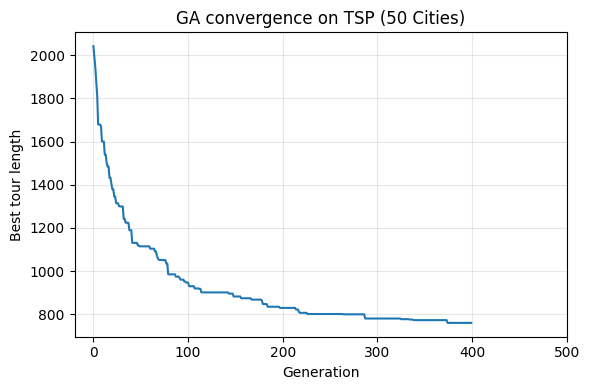

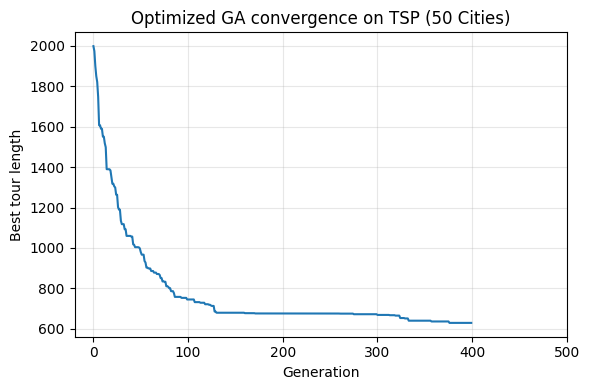

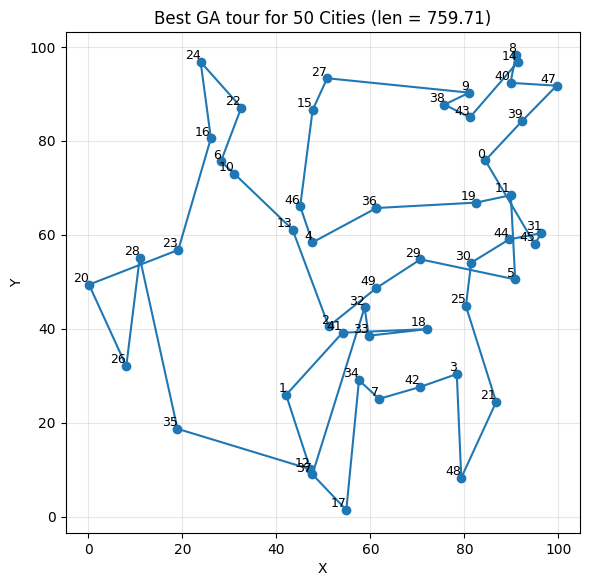

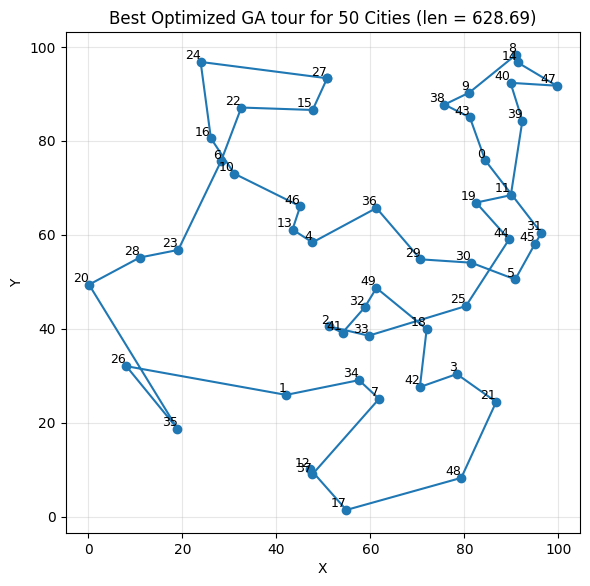

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(ga_best_costs_50)
plt.xlabel("Generation")
plt.ylabel("Best tour length")
plt.title("GA convergence on TSP (50 Cities)")
plt.xlim(xmax=500)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(opt_ga_best_costs_50)
plt.xlabel("Generation")
plt.ylabel("Best tour length")
plt.title("Optimized GA convergence on TSP (50 Cities)")
plt.xlim(xmax=500)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plot_best_tour(coords_50, best_tour_ga_50, title=f"Best GA tour for 50 Cities (len = {best_len_ga_50:.2f})")
plot_best_tour(coords_50, opt_best_tour_ga_50, title=f"Best Optimized GA tour for 50 Cities (len = {opt_best_len_ga_50:.2f})")

According to the Convergence Graphs above, the Optimized version of GA converges to better solutions in earlier iterations compare to the original GA. Moreover, the Optimized version has reached a better solution within the iteration limit. According to the graphs representing the tour of GA, the optimized version has found a less complex path which reflects the quality of the output after optimization.

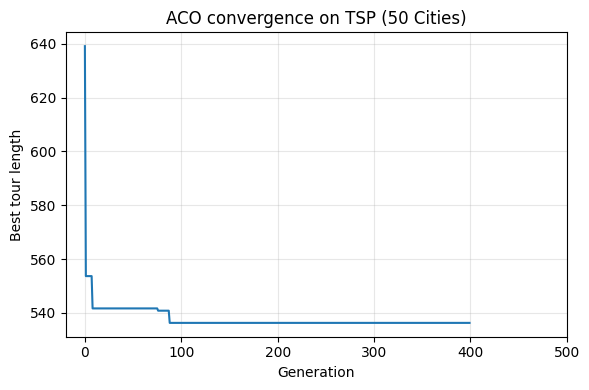

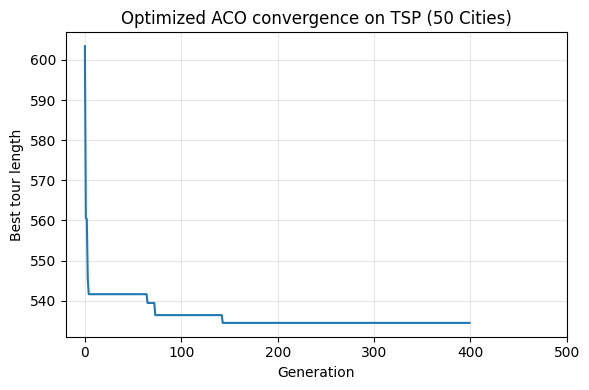

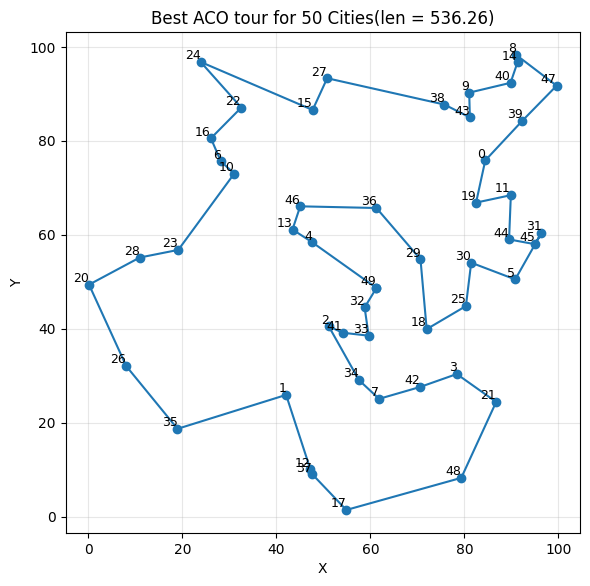

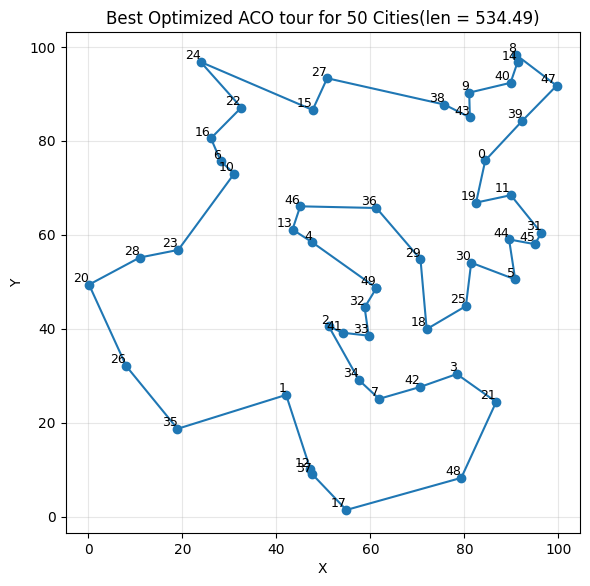

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(aco_best_costs_50)
plt.xlabel("Generation")
plt.ylabel("Best tour length")
plt.title("ACO convergence on TSP (50 Cities)")
plt.xlim(xmax=500)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(opt_aco_best_costs_50)
plt.xlabel("Generation")
plt.ylabel("Best tour length")
plt.title("Optimized ACO convergence on TSP (50 Cities)")
plt.xlim(xmax=500)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plot_best_tour(coords_50, best_tour_aco_50, title=f"Best ACO tour for 50 Cities(len = {best_len_aco_50:.2f})")
plot_best_tour(coords_50, opt_best_tour_aco_50, title=f"Best Optimized ACO tour for 50 Cities(len = {opt_best_len_aco_50:.2f})")

By refering the Convergence graphs above, it can be seen that Optimized ACO converges to better solutions slightly faster than the original ACO. Finally, the Optimized ACO reached a better solution than the Original ACO within the iteration limit. However, there is no drastical improvement in the cost as only two edges are changed in the optimized version.

,Algorithm,Best Cost,Runtime (sec)
0,GA (Original),759.713257,1.259098
1,GA (Optimized),628.686094,4.834443
2,ACO (Original),536.256224,9.420384
3,ACO (Optimized),534.494447,17.105600


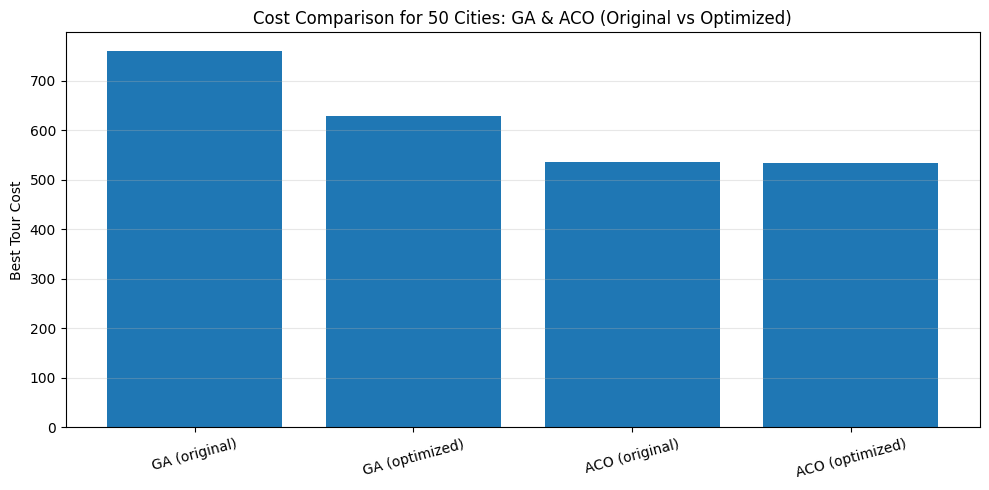

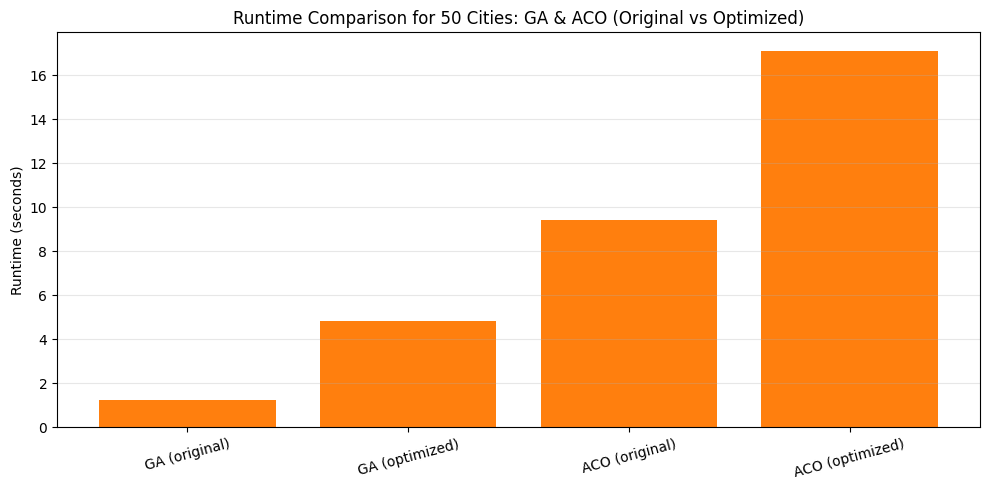

In [ ]:
data = {
    "Algorithm": [
        "GA (Original)", "GA (Optimized)",
        "ACO (Original)", "ACO (Optimized)"
    ],
    "Best Cost": [
        best_len_ga_50, opt_best_len_ga_50,
        best_len_aco_50, opt_best_len_aco_50
    ],
    "Runtime (sec)": [
        elapsed_GA_50, opt_elapsed_GA_50,
        elapsed_ACO_50, opt_elapsed_ACO_50
    ]
}

df = pd.DataFrame(data)

display(df)


# Labels for x-axis
labels = [
    "GA (original)",
    "GA (optimized)",
    "ACO (original)",
    "ACO (optimized)",
]

# Corresponding cost + time arrays
costs = [
    best_len_ga_50,
    opt_best_len_ga_50,
    best_len_aco_50,
    opt_best_len_aco_50,
]

times = [
    elapsed_GA_50,
    opt_elapsed_GA_50,
    elapsed_ACO_50,
    opt_elapsed_ACO_50,
]

x = np.arange(len(labels))  # x positions



#   PLOT 1 — COST Comparison
plt.figure(figsize=(10,5))
plt.bar(x, costs, color="tab:blue")
plt.xticks(x, labels, rotation=15)
plt.ylabel("Best Tour Cost")
plt.title("Cost Comparison for 50 Cities: GA & ACO (Original vs Optimized)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#   PLOT 2 — TIME Comparison
plt.figure(figsize=(10,5))
plt.bar(x, times, color="tab:orange")
plt.xticks(x, labels, rotation=15)
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison for 50 Cities: GA & ACO (Original vs Optimized)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


From the above bar graph related to Cost(Tour length) comparison, it can be seen that both GA and ACO has improved it's performance after Hyper Parameter Optimization(HPO). However, the runtime of both GA and ACO has increased after optimization in order to achieve the improvement.

Optimized GA has achieved a considerable level of improvement, which is worth to invest more time. However, ACO has achieved only a minor improvement by investing considerable amount of time. Therefore, It can be considered not worthwhile to invest time.

**4.3 Execution of GA(Optimized and Original) and ACO(Optimized and Original) for TSP with 100 Cities.**

In [ ]:
#for 100 cities
coords_100, best_tour_ga_100, best_len_ga_100, ga_best_costs_100, elapsed_GA_100, best_tour_aco_100, best_len_aco_100, aco_best_costs_100, elapsed_ACO_100, opt_best_tour_ga_100, opt_best_len_ga_100, opt_ga_best_costs_100, opt_elapsed_GA_100, opt_best_tour_aco_100, opt_best_len_aco_100, opt_aco_best_costs_100, opt_elapsed_ACO_100=execute(100)


=== n = 100 ===


[I 2025-11-23 18:05:45,371] A new study created in memory with name: no-name-907fbcf6-ab50-4294-b6d2-0f5230fcd395
[I 2025-11-23 18:05:48,978] Trial 0 finished with value: 1735.0757516701763 and parameters: {'population_size': 25, 'crossover_rate': 0.9119675168960458, 'mutation_rate': 0.012189694614178044, 'elitism': 2, 'tournament_k': 10, 'generations': 400}. Best is trial 0 with value: 1735.0757516701763.
[I 2025-11-23 18:06:02,803] Trial 1 finished with value: 1317.4025533479332 and parameters: {'population_size': 99, 'crossover_rate': 0.8004481854639751, 'mutation_rate': 0.0015082710453590447, 'elitism': 2, 'tournament_k': 6, 'generations': 400}. Best is trial 1 with value: 1317.4025533479332.
[I 2025-11-23 18:06:27,248] Trial 2 finished with value: 1259.0394545123365 and parameters: {'population_size': 152, 'crossover_rate': 0.9214956144417502, 'mutation_rate': 0.008782888669095604, 'elitism': 1, 'tournament_k': 4, 'generations': 400}. Best is trial 2 with value: 1259.0394545123365

Best Params of GA {'population_size': 395, 'crossover_rate': 0.9514144128572469, 'mutation_rate': 0.004654021350273722, 'elitism': 23, 'tournament_k': 7, 'generations': 400}


[I 2025-11-23 19:21:23,775] A new study created in memory with name: no-name-a2465943-58dd-48b6-a373-43ca0c127240
[I 2025-11-23 19:21:37,684] Trial 0 finished with value: 887.8650073278505 and parameters: {'n_ants': 6, 'alpha': 1.6698781883601719, 'beta': 3.278002383260733, 'rho': 1, 'Q': 979, 'iterations': 400}. Best is trial 0 with value: 887.8650073278505.
[I 2025-11-23 19:22:31,550] Trial 1 finished with value: 858.7191814436818 and parameters: {'n_ants': 24, 'alpha': 1.251680695489907, 'beta': 1.2154545064008528, 'rho': 0, 'Q': 505, 'iterations': 400}. Best is trial 1 with value: 858.7191814436818.
[I 2025-11-23 19:23:54,520] Trial 2 finished with value: 801.4820542908024 and parameters: {'n_ants': 37, 'alpha': 1.705608554156563, 'beta': 2.805572764453646, 'rho': 0, 'Q': 295, 'iterations': 400}. Best is trial 2 with value: 801.4820542908024.
[I 2025-11-23 19:26:36,144] Trial 3 finished with value: 820.262291620658 and parameters: {'n_ants': 76, 'alpha': 0.8200780303698733, 'beta':

Best Params of ACO {'n_ants': 72, 'alpha': 1.3843921417798508, 'beta': 2.19948055015441, 'rho': 0, 'Q': 558, 'iterations': 400}
GA best length : 1602.0591228932597
GA best tour   : [80, 49, 59, 36, 23, 66, 86, 20, 26, 62, 35, 72, 28, 56, 78, 76, 68, 55, 16, 61, 10, 51, 89, 22, 6, 24, 71, 87, 27, 15, 75, 14, 8, 47, 9, 73, 39, 43, 65, 40, 38, 50, 0, 90, 91, 25, 4, 92, 46, 13, 81, 85, 98, 74, 83, 45, 96, 44, 5, 77, 53, 48, 58, 54, 41, 33, 60, 2, 32, 34, 7, 99, 3, 29, 19, 11, 31, 30, 57, 18, 42, 63, 21, 95, 1, 17, 84, 37, 70, 52, 67, 64, 93, 79, 12, 69, 94, 88, 82, 97]
GA runtime  : 4.913046868998208
Optimized GA best length : 1025.6092656157416
Optimized GA best tour   : [72, 78, 68, 23, 56, 76, 20, 66, 28, 55, 51, 10, 6, 16, 13, 46, 92, 4, 59, 90, 36, 81, 32, 41, 60, 80, 2, 97, 82, 88, 1, 79, 70, 7, 34, 42, 85, 95, 33, 49, 98, 30, 29, 96, 44, 39, 47, 40, 14, 8, 65, 9, 38, 75, 50, 15, 22, 87, 24, 71, 61, 89, 27, 73, 43, 0, 19, 11, 31, 45, 5, 57, 25, 18, 91, 21, 83, 3, 77, 53, 74, 63, 48, 

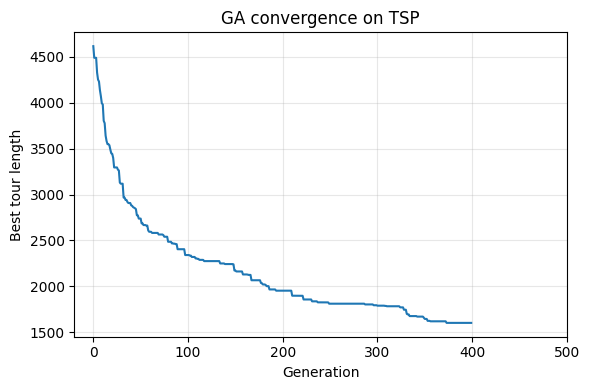

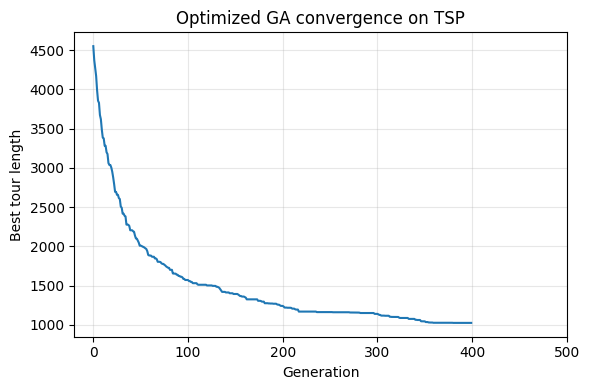

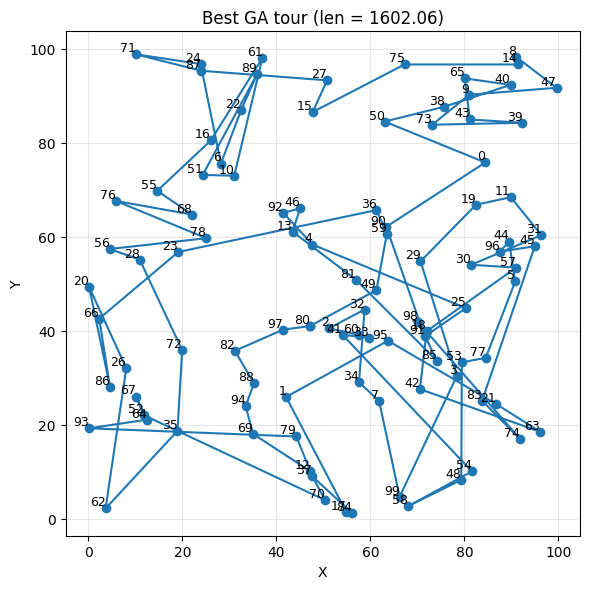

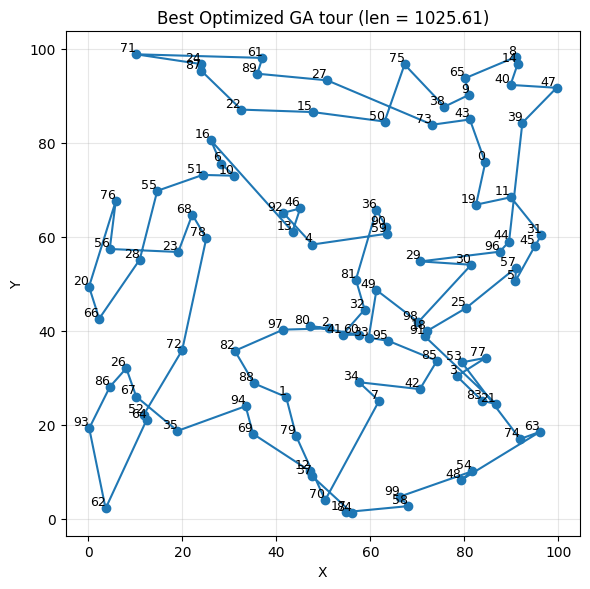

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(ga_best_costs_100)
plt.xlabel("Generation")
plt.ylabel("Best tour length")
plt.title("GA convergence on TSP(100 Cities)")
plt.xlim(xmax=500)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(opt_ga_best_costs_100)
plt.xlabel("Generation")
plt.ylabel("Best tour length")
plt.title("Optimized GA convergence on TSP(100 Cities)")
plt.xlim(xmax=500)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plot_best_tour(coords_100, best_tour_ga_100, title=f"Best GA tour for 100 Cities(len = {best_len_ga_100:.2f})")
plot_best_tour(coords_100, opt_best_tour_ga_100, title=f"Best Optimized GA tour for 100 Cities(len = {opt_best_len_ga_100:.2f})")

According to the Convergence graphs it can be seen that the Optimized GA has reached better solutions at earlier generations. As a result it converges faster and reach a better cost(tour length) within the iteration limit. Moreover, by comparing the tours of both original GA and optimized GA, we can see that the tour of Optimized GA has reduced the complexity of the tour path and finally reduced the total length.

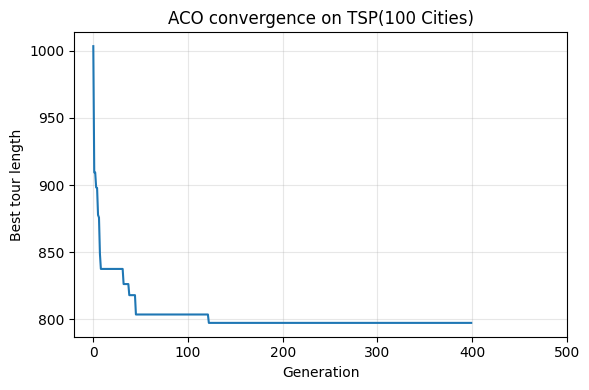

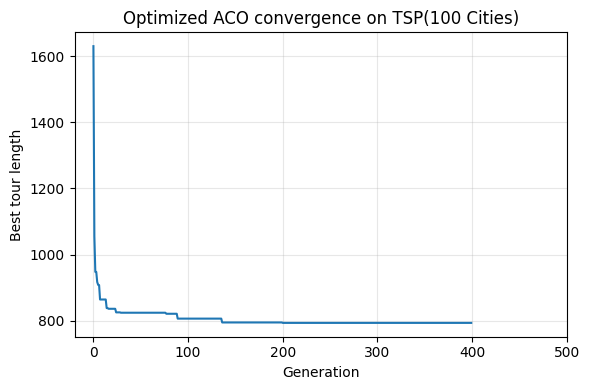

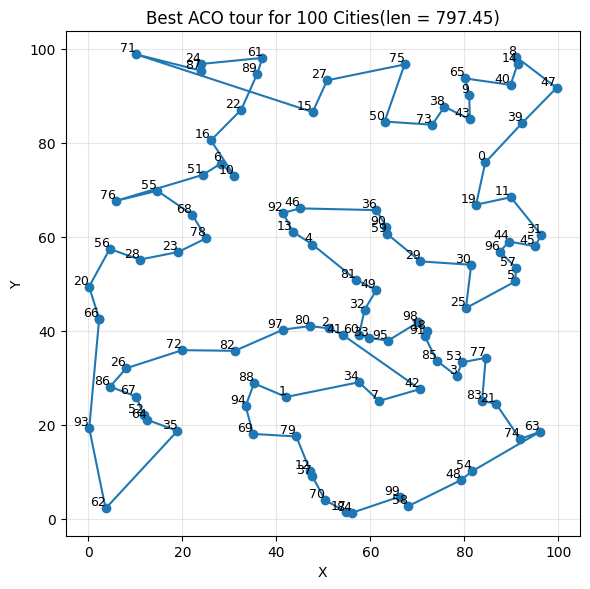

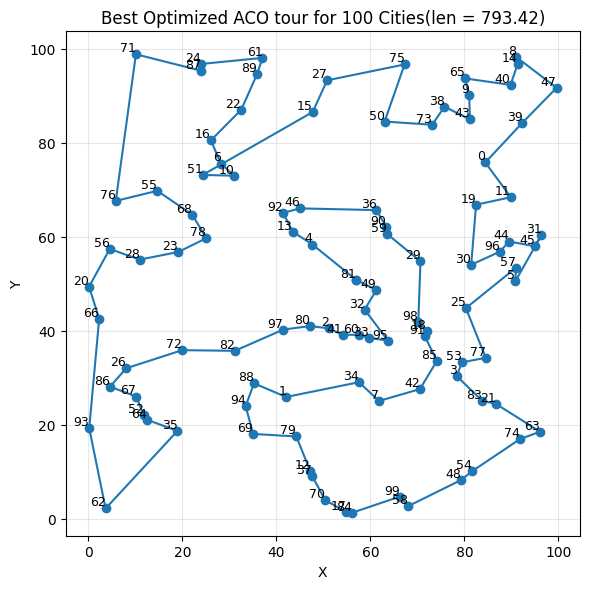

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(aco_best_costs_100)
plt.xlabel("Generation")
plt.ylabel("Best tour length")
plt.title("ACO convergence on TSP(100 Cities)")
plt.xlim(xmax=500)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(opt_aco_best_costs_100)
plt.xlabel("Generation")
plt.ylabel("Best tour length")
plt.title("Optimized ACO convergence on TSP(100 Cities)")
plt.xlim(xmax=500)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plot_best_tour(coords_100, best_tour_aco_100, title=f"Best ACO tour for 100 Cities(len = {best_len_aco_100:.2f})")
plot_best_tour(coords_100, opt_best_tour_aco_100, title=f"Best Optimized ACO tour for 100 Cities(len = {opt_best_len_aco_100:.2f})")

According to the Convergence graphs, it can be seen that the Optimized ACO has reached better solutions at earlier generations. As a result it converges faster and reach a slightly better cost(tour length) within the iteration limit. There is no significant difference between the tour path of both original and optimized ACO. However, Optimized ACO has reached a better final cost.

,Algorithm,Best Cost,Runtime (sec)
0,GA (Original),1602.059123,4.913047
1,GA (Optimized),1025.609266,21.691031
2,ACO (Original),797.454289,72.603525
3,ACO (Optimized),793.415001,53.980039


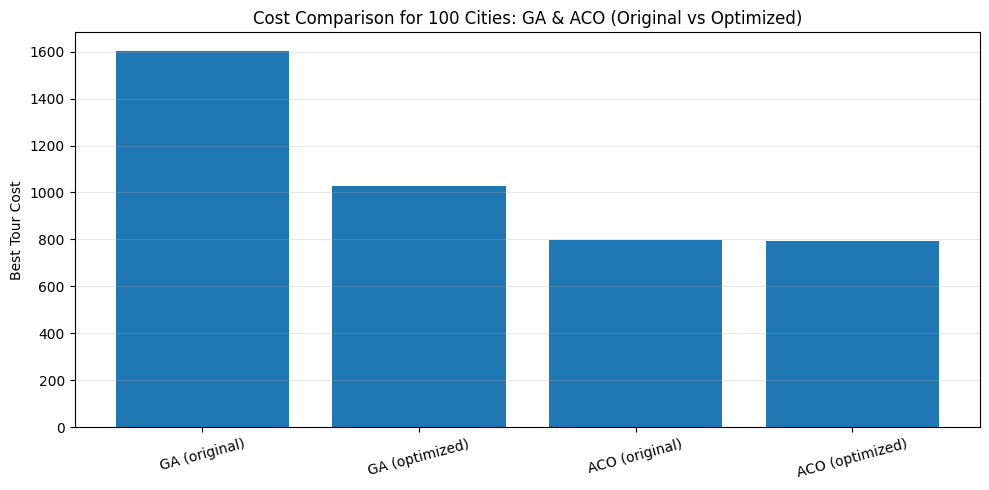

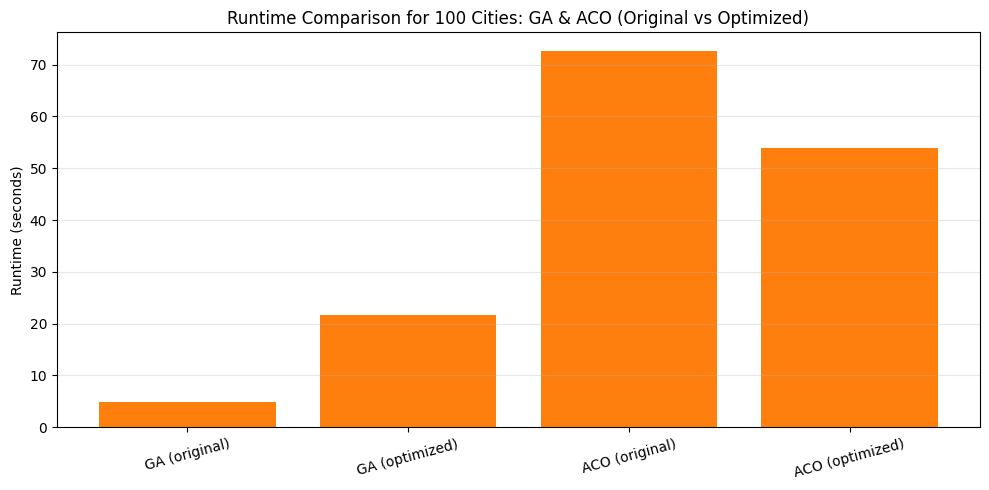

In [ ]:
data = {
    "Algorithm": [
        "GA (Original)", "GA (Optimized)",
        "ACO (Original)", "ACO (Optimized)"
    ],
    "Best Cost": [
        best_len_ga_100, opt_best_len_ga_100,
        best_len_aco_100, opt_best_len_aco_100
    ],
    "Runtime (sec)": [
        elapsed_GA_100, opt_elapsed_GA_100,
        elapsed_ACO_100, opt_elapsed_ACO_100
    ]
}

df = pd.DataFrame(data)

display(df)


# Labels for x-axis
labels = [
    "GA (original)",
    "GA (optimized)",
    "ACO (original)",
    "ACO (optimized)",
]

# Corresponding cost + time arrays
costs = [
    best_len_ga_100,
    opt_best_len_ga_100,
    best_len_aco_100,
    opt_best_len_aco_100,
]

times = [
    elapsed_GA_100,
    opt_elapsed_GA_100,
    elapsed_ACO_100,
    opt_elapsed_ACO_100,
]

x = np.arange(len(labels))  # x positions



#   PLOT 1 — COST Comparison
plt.figure(figsize=(10,5))
plt.bar(x, costs, color="tab:blue")
plt.xticks(x, labels, rotation=15)
plt.ylabel("Best Tour Cost")
plt.title("Cost Comparison for 100 Cities: GA & ACO (Original vs Optimized)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


#   PLOT 2 — TIME Comparison
plt.figure(figsize=(10,5))
plt.bar(x, times, color="tab:orange")
plt.xticks(x, labels, rotation=15)
plt.ylabel("Runtime (seconds)")
plt.title("Runtime Comparison for 100 Cities: GA & ACO (Original vs Optimized)")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


From the above bar graph related to Cost(Tour length) comparison, it can be seen that both GA and ACO has improved it's final cost after optimization. Moreover, from the runtime comparison, it can be seen that, optimization has improved runtime efficiency of both GA and ACO as well.

**In General:**

According to the results obtained after optimization, it can be concluded that, as the number of cities increases and the problem becomes complex, Hyper Parameter Optimization(HPO) becomes more applicable and useful.

# **5. Performance Comparison of GA(Original) and ACO(Original).**

,Algorithm,Best Cost,Runtime (sec)
0,GA (10),239.372468,0.338811
1,ACO (10),239.372468,0.089553
2,GA (50),759.713257,1.259098
3,ACO (50),536.256224,9.420384
4,GA (100),1602.059123,4.913047
5,ACO(100),797.454289,72.603525


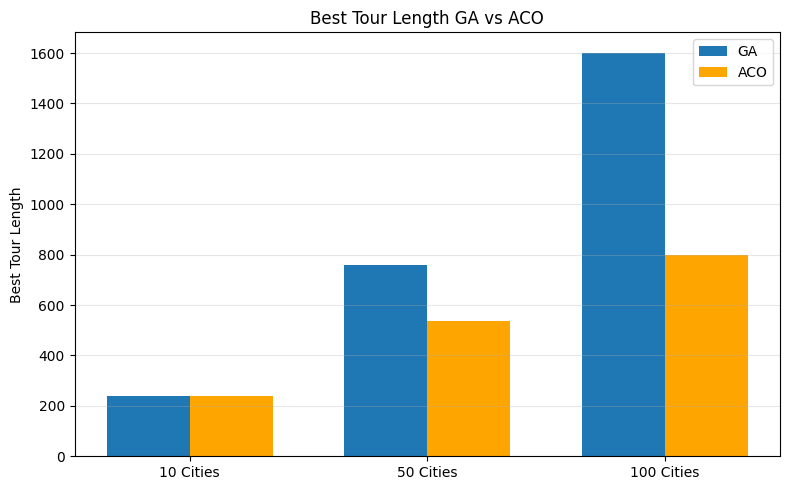

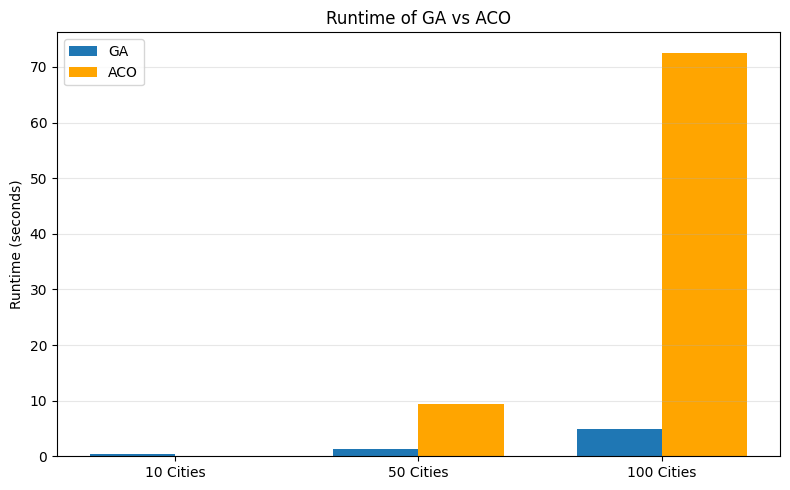

In [ ]:
data = {
    "Algorithm": [
        "GA (10)",  "ACO (10)", "GA (50)",
        "ACO (50)", "GA (100)","ACO(100)"
    ],
    "Best Cost": [
        best_len_ga_10, best_len_aco_10, best_len_ga_50,
        best_len_aco_50, best_len_ga_100, best_len_aco_100
    ],
    "Runtime (sec)": [
        elapsed_GA_10,  elapsed_ACO_10, elapsed_GA_50,
        elapsed_ACO_50, elapsed_GA_100, elapsed_ACO_100
    ]
}

df = pd.DataFrame(data)

display(df)


algos = ["10 Cities", "50 Cities", "100 Cities"]
before = [best_len_ga_10, best_len_ga_50, best_len_ga_100]
after  = [best_len_aco_10, best_len_aco_50, best_len_aco_100]

x = np.arange(len(algos))
w = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - w/2, before, width=w, label="GA")
plt.bar(x + w/2, after,  width=w, label="ACO", color="orange")

plt.xticks(x, algos)
plt.ylabel("Best Tour Length")
plt.title("Best Tour Length GA vs ACO")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


algos = ["10 Cities", "50 Cities", "100 Cities"]
before = [elapsed_GA_10, elapsed_GA_50, elapsed_GA_100]
after  = [elapsed_ACO_10, elapsed_ACO_50, elapsed_ACO_100]

x = np.arange(len(algos))
w = 0.35

plt.figure(figsize=(8,5))

plt.bar(x - w/2, before, width=w, label="GA")
plt.bar(x + w/2, after,  width=w, label="ACO", color="orange")

plt.xticks(x, algos)
plt.ylabel("Runtime (seconds)")
plt.title("Runtime of GA vs ACO")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

According to the above Best Tour Length(=Cost) comparison of GA and ACO, when there are only 10 Cities in TSP problem, both GA and ACO has achieved the same final cost(Tour length). However the runtime efficiency of ACO is better.

When there are 50 Cities, the best tour length of ACO is considerably better than GA. However, from the runtime comparison, it can be seen that the ACO has invested much time than GA in order to achieve the improved tour length.

When there are 100 cities, the final tour length achieved by ACO is significantly better than GA. However, ACO has invested a large amount of time in order to achieve that improved result.

# **Appendix**

In [ ]:
def obj_ga_pilot( trial: optuna.Trial,dist) -> float:
  pop_size     = trial.suggest_int("population_size", 20, 400, log=True)
  cx_rate      = trial.suggest_float("crossover_rate", 0.6, 1.0)
  mut_rate     = trial.suggest_float("mutation_rate", 1e-3, 0.3, log=True)
  elite_size   = trial.suggest_int("elitism", 0, max(1, pop_size // 10))
  tournament_k = trial.suggest_int("tournament_k", 2, min(10, pop_size))

  generations  = trial.suggest_int("generations", 50, 500, log=True)

  seeds = (0, 42, 777)
  costs= []
  for s in seeds:
      _, best_len,_= GA(
          dist,
          generations=generations,
          seed=s,
          pop_size=pop_size,
          cx_rate=cx_rate,
          mut_rate=mut_rate,
          elite_size=elite_size,
          tournament_k=tournament_k
      )


      costs.append(float(best_len))


  mean_cost = sum(costs) / len(costs)

  # For logging/analysis
  trial.set_user_attr("mean_cost", mean_cost)


  return mean_cost

In [ ]:
def obj_aco_pilot(trial: optuna.Trial, dist) -> float:
  n_ants = trial.suggest_int("n_ants", 5, 100, log=True)
  alpha = trial.suggest_float("alpha", 0.5, 2.0)
  beta = trial.suggest_float("beta", 1, 15, log=True)
  rho = trial.suggest_int("rho", 0, 1)
  Q = trial.suggest_int("Q", 10, 1000)

  iterations  = trial.suggest_int("iterations", 50, 500, log=True)

  seeds = (0, 42, 777)
  costs= []
  for s in seeds:
    _, best_len,_ = ACO(
        dist,
        iterations=iterations,
        seed=s,
        n_ants=n_ants,
        alpha=alpha,
        beta=beta,
        rho=rho,
        Q=Q
    )

    costs.append(float(best_len))

  mean_cost = sum(costs) / len(costs)

  # For logging/analysis
  trial.set_user_attr("mean_cost", mean_cost)

  return mean_cost

In [ ]:
def run_pilot(algo, dist, n_trials=80):
    best_cost_history = []   # stores best cost after each trial

    def callback(study, trial):
        # append the best cost so far at each trial
        best_cost_history.append(study.best_value)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=7)
    )

    if(algo=="GA"):
        study.optimize(lambda trial: obj_ga_pilot(trial, dist),
                   n_trials=n_trials,
                   callbacks=[callback])
    else:
        study.optimize(lambda trial: obj_aco_pilot(trial, dist),
                   n_trials=n_trials,callbacks=[callback])



    return study, best_cost_history


In [ ]:
def plot_cost_plateau(best_cost_history):
    plt.figure(figsize=(8,5))
    plt.plot(best_cost_history, linewidth=2)
    plt.xlabel("Trial number")
    plt.ylabel("Best cost so far")
    plt.title("GA Optuna Pilot Study — Cost Plateau Detection")
    plt.grid(True, alpha=0.3)
    plt.show()

[I 2025-11-23 07:34:02,276] A new study created in memory with name: no-name-92688e18-79e2-418f-b182-8591593493e5
[I 2025-11-23 07:34:02,742] Trial 0 finished with value: 969.8013551567715 and parameters: {'population_size': 25, 'crossover_rate': 0.9119675168960458, 'mutation_rate': 0.012189694614178044, 'elitism': 2, 'tournament_k': 10, 'generations': 172}. Best is trial 0 with value: 969.8013551567715.
[I 2025-11-23 07:34:05,068] Trial 1 finished with value: 781.7700943594115 and parameters: {'population_size': 89, 'crossover_rate': 0.6288204533439046, 'mutation_rate': 0.004623340751759673, 'elitism': 4, 'tournament_k': 8, 'generations': 318}. Best is trial 1 with value: 781.7700943594115.
[I 2025-11-23 07:34:05,678] Trial 2 finished with value: 893.6195610107296 and parameters: {'population_size': 62, 'crossover_rate': 0.626374538762362, 'mutation_rate': 0.0051733467498489725, 'elitism': 6, 'tournament_k': 3, 'generations': 141}. Best is trial 1 with value: 781.7700943594115.
[I 202

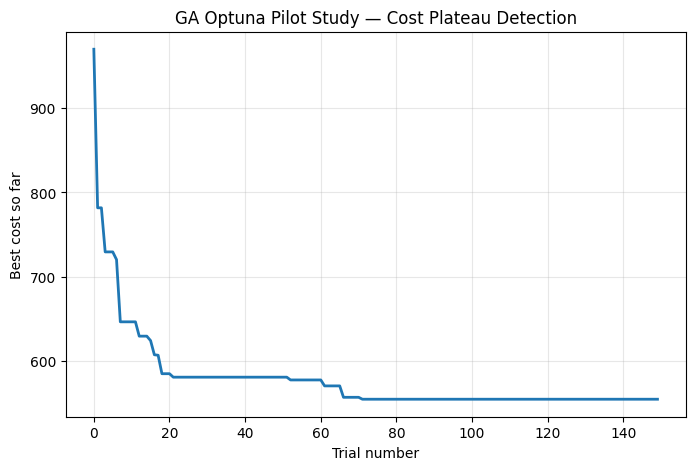

Best cost found: 554.848548445304


In [ ]:
coords = generate_TSP(50)           # or 10, 100 etc.
dist   = build_distance_matrix(coords)

study, pilot_curve = run_pilot("GA",dist, n_trials=150)
plot_cost_plateau(pilot_curve)

print("Best cost found:", study.best_value)

[I 2025-11-23 09:08:00,807] A new study created in memory with name: no-name-2425d05c-ab93-485e-9251-7aca89f6d167
[I 2025-11-23 09:08:02,042] Trial 0 finished with value: 570.8790910709391 and parameters: {'n_ants': 6, 'alpha': 1.6698781883601719, 'beta': 3.278002383260733, 'rho': 1, 'Q': 979, 'iterations': 172}. Best is trial 0 with value: 570.8790910709391.
[I 2025-11-23 09:08:09,352] Trial 1 finished with value: 610.4063212901609 and parameters: {'n_ants': 21, 'alpha': 0.6080767000396423, 'beta': 2.068753462894505, 'rho': 0, 'Q': 683, 'iterations': 318}. Best is trial 0 with value: 570.8790910709391.
[I 2025-11-23 09:08:11,727] Trial 2 finished with value: 558.7658801144574 and parameters: {'n_ants': 15, 'alpha': 0.5989045203588577, 'beta': 2.1821546236170235, 'rho': 1, 'Q': 221, 'iterations': 141}. Best is trial 2 with value: 558.7658801144574.
[I 2025-11-23 09:08:26,957] Trial 3 finished with value: 535.925724978818 and parameters: {'n_ants': 81, 'alpha': 0.5373488413255221, 'beta

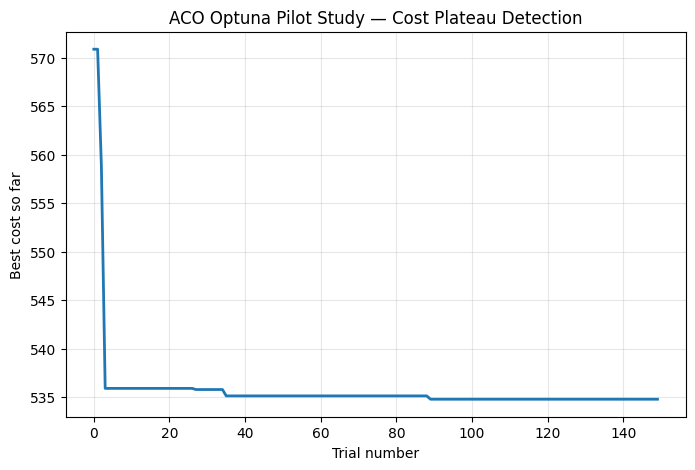

Best cost found: 534.8079213764594


In [ ]:
coords = generate_TSP(50)           # or 10, 100 etc.
dist   = build_distance_matrix(coords)

study, pilot_curve = run_pilot("ACO",dist, n_trials=150)

plt.figure(figsize=(8,5))
plt.plot(pilot_curve, linewidth=2)
plt.xlabel("Trial number")
plt.ylabel("Best cost so far")
plt.title("ACO Optuna Pilot Study — Cost Plateau Detection")
plt.grid(True, alpha=0.3)
plt.show()

print("Best cost found:", study.best_value)